# Step 2: Feature Engineering
**FreshGuard ML Pipeline**

This is where AI becomes real. We extract **behavior-based features** that describe patterns, not fixed thresholds.

> *'These features describe product behavior over time, not fixed conditions.'*

## 2.1 Engineered Features

| Feature | Formula | Why it matters |
|---|---|---|
| `sell_through_rate` | units_sold / initial_quantity | % of stock already sold |
| `remaining_quantity` | initial_quantity - units_sold | Unsold stock |
| `stock_pressure_ratio` | remaining / avg_daily_sales | Days of stock vs sales speed |
| `velocity_score` | daily_demand / shelf_life_days | Fast vs slow moving |
| `expiry_pressure_index` | days_until_expiry / (stock_pressure+1) | Combined urgency |
| `price_margin_ratio` | (price - cost) / price | Margin indicator |

Loaded cleaned dataset: (100000, 54)
Total features selected: 22
Selected features:
['days_until_expiry', 'initial_quantity', 'shelf_life_days', 'storage_temp', 'temp_deviation', 'spoilage_sensitivity', 'units_sold', 'daily_demand', 'sell_through_rate', 'remaining_quantity', 'stock_pressure_ratio', 'velocity_score', 'sales_volatility', 'expiry_pressure_index', 'price_margin_ratio', 'category_encoded', 'region_encoded', 'is_weekend', 'is_promoted', 'handling_score', 'packaging_score', 'supplier_score']
=== Feature Correlation with Target ===
sell_through_rate       -0.482
remaining_quantity       0.378
expiry_pressure_index    0.358
units_sold              -0.268
is_weekend              -0.173
stock_pressure_ratio     0.125
velocity_score           0.122
daily_demand             0.094
days_until_expiry       -0.068
category_encoded         0.063
shelf_life_days         -0.060
initial_quantity        -0.052
storage_temp            -0.033
region_encoded          -0.006
is_promoted        

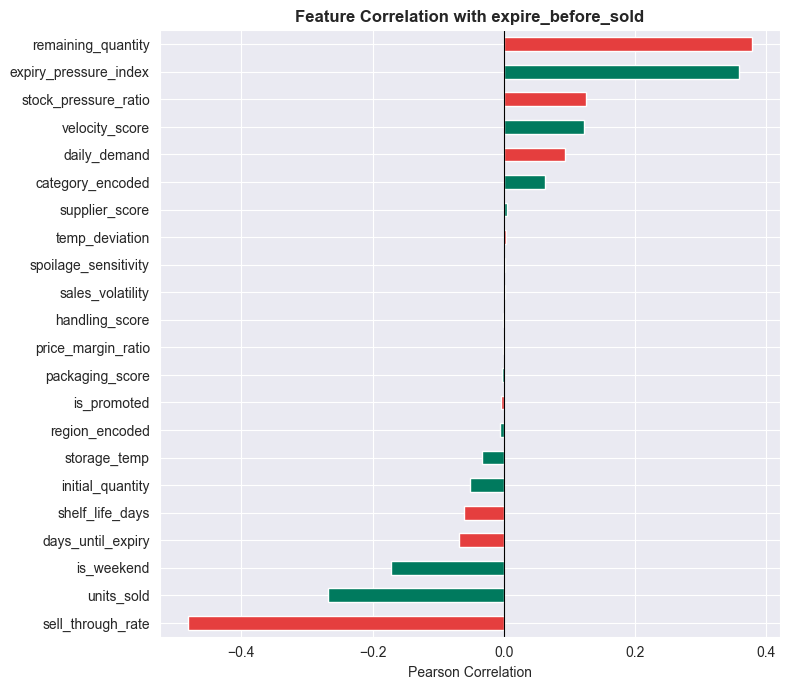

Feature dataset saved: (100000, 23)
Saved outputs/feature_list.json
Saved outputs/encoding_maps.json


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, json, warnings
warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

df = pd.read_csv('outputs/cleaned_dataset.csv')
print(f'Loaded cleaned dataset: {df.shape}')
df.head(2)

def safe_series_div(numerator, denominator, default=np.nan):
    result = numerator / denominator.replace(0, np.nan)
    result = result.replace([np.inf, -np.inf], np.nan)
    return result.fillna(default)

# Core engineered features
df['sell_through_rate'] = safe_series_div(df['units_sold'], df['initial_quantity'], default=0).clip(0, 1)
df['remaining_quantity'] = (df['initial_quantity'] - df['units_sold']).clip(lower=0)

# High value = more stock pressure
df['stock_pressure_ratio'] = safe_series_div(df['remaining_quantity'], df['daily_demand'])

# Sales speed relative to shelf life
df['velocity_score'] = safe_series_div(df['daily_demand'], df['shelf_life_days'])

# Sales volatility
df['sales_volatility'] = df['demand_variability']

# High value = harder to clear stock before expiry
df['expiry_pressure_index'] = safe_series_div(df['stock_pressure_ratio'], df['days_until_expiry'] + 1)

# Margin ratio
df['price_margin_ratio'] = safe_series_div(df['base_price'] - df['cost_price'], df['base_price'], default=0)

# Stable categorical encoding maps
category_values = sorted(df['category'].dropna().astype(str).unique().tolist())
region_values = sorted(df['region'].dropna().astype(str).unique().tolist())

category_map = {value: idx for idx, value in enumerate(category_values)}
region_map = {value: idx for idx, value in enumerate(region_values)}

df['category_encoded'] = df['category'].astype(str).map(category_map).astype(int)
df['region_encoded'] = df['region'].astype(str).map(region_map).astype(int)

FEATURES = [
    'days_until_expiry',
    'initial_quantity',
    'shelf_life_days',
    'storage_temp',
    'temp_deviation',
    'spoilage_sensitivity',
    'units_sold',
    'daily_demand',
    'sell_through_rate',
    'remaining_quantity',
    'stock_pressure_ratio',
    'velocity_score',
    'sales_volatility',
    'expiry_pressure_index',
    'price_margin_ratio',
    'category_encoded',
    'region_encoded',
    'is_weekend',
    'is_promoted',
    'handling_score',
    'packaging_score',
    'supplier_score'
]

TARGET = 'expire_before_sold'

# Final cleanup for features
df[FEATURES] = df[FEATURES].replace([np.inf, -np.inf], np.nan)
feature_medians = df[FEATURES].median(numeric_only=True)
df[FEATURES] = df[FEATURES].fillna(feature_medians)

print(f'Total features selected: {len(FEATURES)}')
print('Selected features:')
print(FEATURES)

corr = df[FEATURES + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False)
print('=== Feature Correlation with Target ===')
print(corr.round(3))

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#E53E3E' if v < 0 else '#007A5E' for v in corr]
corr.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Correlation with expire_before_sold', fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('outputs/feature_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

df_features = df[FEATURES + [TARGET]].copy()
df_features.to_csv('outputs/feature_dataset.csv', index=False)

with open('outputs/feature_list.json', 'w') as f:
    json.dump(
        {
            'features': FEATURES,
            'target': TARGET,
            'feature_medians': {k: float(v) for k, v in feature_medians.to_dict().items()}
        },
        f,
        indent=2
    )

with open('outputs/encoding_maps.json', 'w') as f:
    json.dump(
        {
            'category_map': category_map,
            'region_map': region_map
        },
        f,
        indent=2
    )

print(f'Feature dataset saved: {df_features.shape}')
print('Saved outputs/feature_list.json')
print('Saved outputs/encoding_maps.json')


## Summary

Engineered features now support a safer pre-expiry model:
- `sell_through_rate` — % of stock already sold
- `remaining_quantity` — stock still unsold
- `stock_pressure_ratio` — unsold stock relative to demand
- `expiry_pressure_index` — stock pressure adjusted by time left
- `price_margin_ratio` — pricing flexibility

Key fixes in this updated version:
- removed leakage-prone `waste_pct` from the model features
- saved stable `category_map` and `region_map` for deployment
- stored feature medians for safer missing-value handling in Step 6
